# 기초통계 과제: DailyBox 마케팅 전략 분석 (템플릿)

`marketing_assignment_instructions.md`의 문항 번호에 맞춰 빈칸(`____`)을 채우고, 마크다운 셀에 해석/결론을 서술하세요. 여러분은 DailyBox 전략팀 분석가입니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.outliers_influence import variance_inflation_factor

plt.rcParams['font.family'] = 'AppleGothic'   # Windows는 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

df = pd.read_csv('marketing_customers.csv')
df.head()

,customer_id,age,gender,signup_channel,membership_tier,monthly_visits,avg_discount_rate,online_ad_cost,offline_ad_cost,total_ad_cost,campaign_group,responded,monthly_spend
0,1,21,Female,Organic Search,Basic,10,0.140,16.56,0.34,16.90,control,0,35.10
1,2,47,Female,Referral,Silver,7,0.037,7.45,8.00,15.45,treatment,0,55.42
2,3,42,Female,Social Ads,Silver,8,0.347,20.54,6.92,27.46,treatment,1,86.58
3,4,27,Female,Referral,Silver,5,0.269,9.98,2.80,12.78,control,0,20.63
4,5,26,Female,Social Ads,Basic,13,0.157,6.83,0.57,7.40,treatment,1,25.43


## Part 1. 고객 이해 (EDA)

**1. 데이터 로드 및 구조 확인**

In [2]:
print(df.shape)
print(df.dtypes)
print(df.describe())
print(df.head)   

(6000, 13)
customer_id            int64
age                    int64
gender                object
signup_channel        object
membership_tier       object
monthly_visits         int64
avg_discount_rate    float64
online_ad_cost       float64
offline_ad_cost      float64
total_ad_cost        float64
campaign_group        object
responded              int64
monthly_spend        float64
dtype: object
       customer_id          age  monthly_visits  avg_discount_rate  \
count  6000.000000  6000.000000     6000.000000        6000.000000   
mean   3000.500000    40.263333        8.201500           0.171374   
std    1732.195139    11.513402        4.221437           0.096024   
min       1.000000    18.000000        1.000000           0.000000   
25%    1500.750000    32.000000        5.000000           0.098000   
50%    3000.500000    40.000000        8.000000           0.158000   
75%    4500.250000    48.000000       11.000000           0.233250   
max    6000.000000    78.000000       

> ✍️ 고객 규모와 주요 수치 변수 범위를 한두 줄로 요약하세요.
데이터는 총 6,000명의 고객과 13개의 변수로 구성되어 있다. 주요 수치 변수는 연령(18-78세), 월 방문 횟수(1-34회), 평균 할인율(0~0.5) 등의 범위를 가지며, 전반적인 분포를 기초 통계량을 통해 확인하였다.

**2. 매출 분포와 로그변환** — monthly_spend 왜도 계산 + log1p 전/후 비교

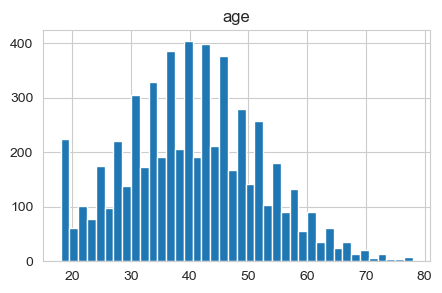

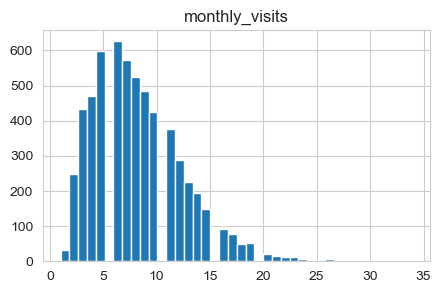

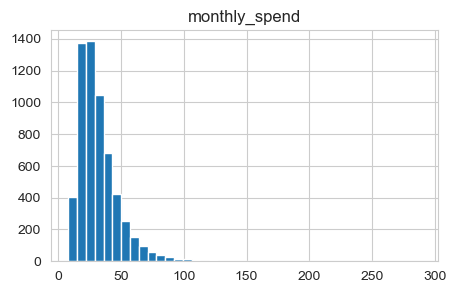

왜도 = 2.5456526289788064


/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


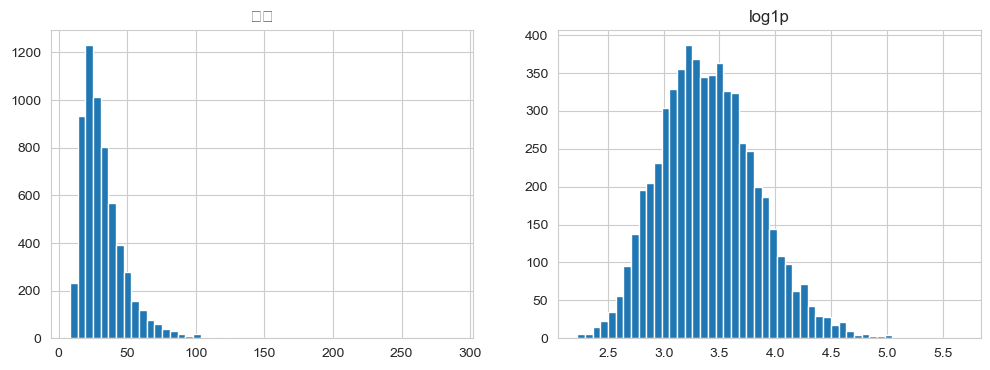

In [3]:
# 분포를 확인할 수치형 변수 목록
for col in ['age', 'monthly_visits', 'monthly_spend']:
    plt.figure(figsize=(5, 3))          # 각 그래프의 크기 설정
    plt.hist(df[col], bins=40)          # 데이터를 40개 구간으로 나누어 히스토그램 생성
    plt.title(col)                      # 그래프 제목을 변수명으로 설정
    plt.show()                          # 그래프 출력

# monthly_spend 변수의 왜도 계산
# 왜도가 0에 가까우면 대칭, 양수면 오른쪽 꼬리가 긴 분포
skew = df['monthly_spend'].skew()
print('왜도 =', skew)

# 원본 데이터와 로그 변환된 데이터의 분포 비교
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# monthly_spend 원본 분포
axes[0].hist(df['monthly_spend'], bins=50)
axes[0].set_title('원본')

# log1p(x)는 log(1 + x)를 계산하며, 0이 포함된 데이터에도 사용할 수 있음
axes[1].hist(np.log1p(df['monthly_spend']), bins=50)
axes[1].set_title('log1p')

plt.show()  # 두 그래프 출력

> ✍️ 매출 분포가 왜 치우쳐 있는지, 로그변환이 왜 도움이 되는지 서술하세요.
월 매출은 대부분의 고객이 낮은 금액에 분포하고, 일부 고객만 매우 높은 매출을 기록하여 오른쪽으로 치우친 분포를 보인다. 이러한 분포는 분석 결과가 극단값의 영향을 크게 받을 수 있으므로, 로그 변환을 적용하면 분포가 보다 대칭적으로 변하고 왜도가 감소하여 데이터 분석과 모델 학습에 도움이 된다.

**3. 채널·등급별 매출 Boxplot**

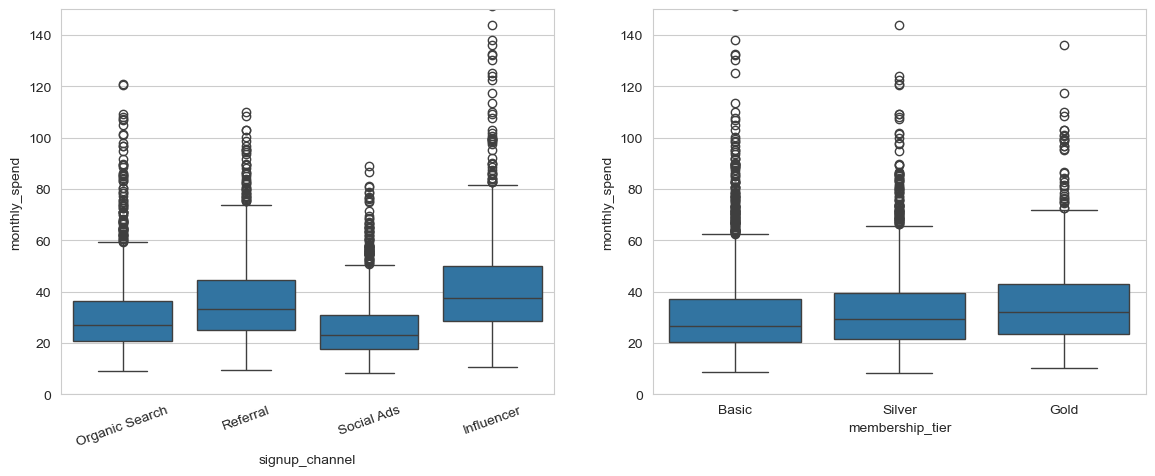

In [4]:
# plt.subplots(1, 2): 1행 2열로 그래프 칸 2개 생성
# figsize=(14, 5): 전체 그림 크기를 가로 14, 세로 5로 설정
# fig: 전체 그림 객체
# axes: 각각의 그래프 칸을 담고 있는 객체
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# sns.boxplot(): 박스플롯을 그리는 함수
# data=df: df 데이터프레임 사용
# x='signup_channel': x축에 signup_channel 열 사용
# y='monthly_spend': y축에 monthly_spend 열 사용
# ax=axes[0]: 첫 번째 그래프 칸, 즉 왼쪽에 그리기
sns.boxplot(
    data=df,
    x='signup_channel',
    y='monthly_spend',
    ax=axes[0]
)

# axes[0]: 왼쪽 그래프 선택
# set_ylim(0, 150): y축 범위를 0부터 150까지로 설정
axes[0].set_ylim(0, 150)

# tick_params(): 축 눈금 글자 모양 설정
# axis='x': x축 눈금에 적용
# rotation=20: x축 글자를 20도 회전
axes[0].tick_params(axis='x', rotation=20)

# 두 번째 박스플롯 생성
# x='membership_tier': x축에 membership_tier 열 사용
# order=[...]: x축 범주의 출력 순서를 직접 지정
# ax=axes[1]: 두 번째 그래프 칸, 즉 오른쪽에 그리기
sns.boxplot(
    data=df,
    x='membership_tier',
    y='monthly_spend',
    order=['Basic', 'Silver', 'Gold'],
    ax=axes[1]
)

# 오른쪽 그래프의 y축 범위를 0부터 150까지로 설정
axes[1].set_ylim(0, 150)

# 지금까지 만든 그래프를 화면에 출력
plt.show()

> ✍️ 어떤 채널/등급이 고가치 고객으로 보이는지 해석하세요.
Influencer 채널과 Gold 멤버십이 상대적으로 고가치 고객 집단으로 보인다.

## Part 2. 가정 확인

**4. 1종/2종 오류 (개념)**

> ✍️ "쿠폰 캠페인은 효과가 없다"는 H0에 대해 1종 오류와 2종 오류가 각각 무엇을 의미하고, 어떤 손실을 끼치는지 서술하세요.


1종 오류는 실제로 쿠폰 캠페인에 효과가 없는데도 효과가 있다고 판단하는 경우이다. 이 경우 효과 없는 캠페인을 계속 운영하게 되어 쿠폰 비용, 광고비, 운영비 등이 낭비될 수 있다.
2종 오류는 실제로 쿠폰 캠페인에 효과가 있는데도 효과가 없다고 판단하는 경우이다. 이 경우 효과적인 캠페인을 중단하거나 도입하지 않아 추가 매출과 고객 확보 기회를 놓칠 수 있다.

**5. 정규성 검정 (Shapiro-Wilk) — 원본 vs 로그**

: 수집한 데이터가 종 모양의 좌우 대칭 형태인 정규분포를 따르는지 통계적으로 확인하는 과정
( 통계 검정이 데이터가 정규분포를 따른다고 가정하는 경우가 많기 때문 )


검정이란?
: 데이터를 보고 주장이 가설이 얼마나 믿을만한지를 판단하는 것

기본 주장을 귀무가설 H_0이라고 한다.
이에 반대되는 주장은 대립가설 H_1이다.

예를 들어 정규성 검정은
: 정말 정규분포에서 뽑힌 데이터라면 지금의 데이터가 나올 가능성이 얼마나 되는가? 를 다룬다.

p-value 는 귀무가설이 맞다고 가정했을 때, 현재 결과만큼 예상에서 벗어난 결과가 나올 가능성



Shapiro-Wilk 검정은 데이터가 얼마나 정규분포에 가까운지를 검사하는 정규성 검정이다.
: 검정통계량 statistic이 1에 가까울수록 정규분포에 가깝다.
마찬가지로 p-value도 사용한다.


/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


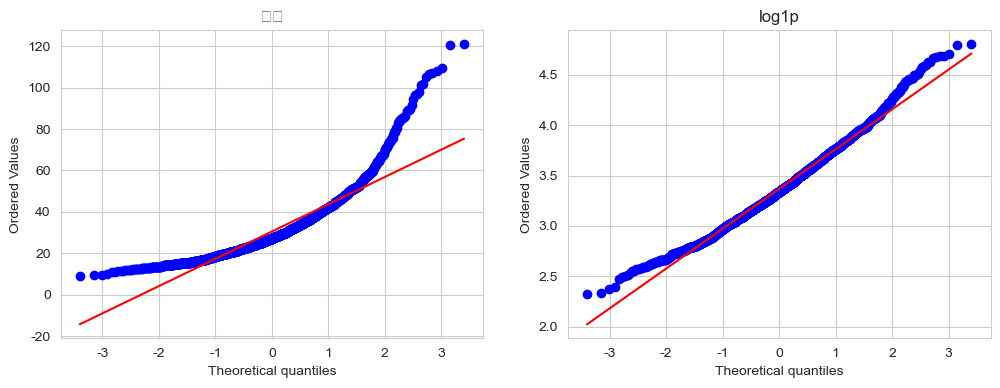

원본   ShapiroResult(statistic=np.float64(0.853453397638087), pvalue=np.float64(3.631642400264097e-21))
log1p  ShapiroResult(statistic=np.float64(0.9873230180962402), pvalue=np.float64(0.00024486116128258806))


In [5]:
# df.loc[조건, 열 이름]:
# df에서 signup_channel이 'Organic Search'인 행만 고르고,
# 그중 monthly_spend 열만 가져와 x에 저장
x = df.loc[df.signup_channel == 'Organic Search', 'monthly_spend']


# plt.subplots(1, 2): 그래프를 1행 2열로 나란히 생성
# figsize=(12, 4): 전체 그래프 크기를 가로 12, 세로 4로 설정
# fig: 전체 그림 객체
# axes: 왼쪽과 오른쪽 그래프를 담는 객체
fig, axes = plt.subplots(1, 2, figsize=(12, 4))


# stats.probplot(): 데이터가 특정 분포와 얼마나 비슷한지 Q-Q plot으로 확인
# Q-Q plot상의 점들이 대각선에 거의 붙어 있으면 정규분포에 가깝다는 의미
# x: 검사할 원본 월 지출액 데이터
# dist='norm': 정규분포와 비교
# plot=axes[0]: 왼쪽 그래프 칸에 출력
stats.probplot(x, dist='norm', plot=axes[0])

# axes[0]: 왼쪽 그래프 선택
# set_title('원본'): 왼쪽 그래프 제목 설정
axes[0].set_title('원본')


# np.log1p(x): x의 각 값에 log(1 + x)를 적용
# 로그 변환된 월 지출액이 정규분포에 가까워졌는지 확인
# plot=axes[1]: 오른쪽 그래프 칸에 출력
stats.probplot(np.log1p(x), dist='norm', plot=axes[1])

# 오른쪽 그래프 제목 설정
axes[1].set_title('log1p')


# 지금까지 만든 두 그래프를 화면에 출력
plt.show()


# x.sample(500): x에서 500개의 데이터를 무작위로 추출
# random_state=0: 실행할 때마다 동일한 표본이 선택되도록 난수 기준을 고정
xs = x.sample(500, random_state=0)


# stats.shapiro(): Shapiro-Wilk 정규성 검정 수행
# 원본 데이터가 정규분포를 따르는지 검사
print('원본  ', stats.shapiro(xs))


# np.log1p(xs): 표본에 로그 변환 적용
# 로그 변환된 데이터가 정규분포를 따르는지 검사
print('log1p ', stats.shapiro(np.log1p(xs)))

> ✍️ 가설을 세우고, 두 결과를 0.05 기준으로 비교 해석하세요.

귀무가설(H₀): 데이터는 정규분포를 따른다.
대립가설(H₁): 데이터는 정규분포를 따르지 않는다.

원본 데이터의 Shapiro-Wilk 검정 결과 p-value는 0.05보다 작으므로 귀무가설을 기각한다. 따라서 원본 데이터는 정규분포를 따른다고 보기 어렵다.

로그 변환한 데이터의 p-value는 0.000245로 원본보다 크게 증가하여 정규성이 개선되었지만, 여전히 0.05보다 작으므로 귀무가설을 기각한다. 따라서 로그 변환 후에도 엄밀하게는 정규분포를 따른다고 볼 수는 없지만, 원본보다 정규분포에 더 가까워진 것으로 해석할 수 있다.

**6. 등분산성 검정**


일반적인 ANOVA나 일부 t-test는 보통 각 집단의 분산이 비슷하다는 가정을 사용

따라서 등분산성을 Levene 검정으로 확인하자.

In [6]:
# signup_channel별로 데이터를 나누고,
# 각 채널의 monthly_spend 값을 NumPy 배열로 저장
groups = [
    g['monthly_spend'].values
    for _, g in df.groupby('signup_channel')
]

# stats.levene(): 여러 집단의 분산이 같은지 확인하는 Levene 검정
# *groups: 리스트 안에 있는 각 채널의 배열을 함수에 각각 전달
# stat: 검정통계량, p: p-value
stat, p = stats.levene(*groups)

# Levene 검정의 p-value 출력
print('Levene p =', p)

Levene p = 4.335927248200273e-44


> ✍️ p값을 0.05 기준으로 해석하고, ANOVA에 어떤 의미인지 서술하세요.

등분산성 검정 결과 Levene p = 4.335927248200273e-44로 0.05보다 작으므로 귀무가설이 기각되며, 따라서 가입 채널별 월 지출액의 분산은 동일하지 않다.




ANOVA는 여러 집단의 평균을 비교하는 통계 검정이다.

예를 들어 가입 채널이 여러개일 때 '가입 챠널에 따라 고객의 평균 월 지출액이 다른가?'처럼
여러 집단의 평균을 한번에 비교할때 사용된다.

다만 주의할 점은 평균을 비교하는 것처럼 보이지만, 실제 계산에서는 대이터가 얼마나 퍼져있는지 -분산- 를 비교한다.

ANOVA는 집단의 평균이 서로 얼마나 떨어져있는지를 보고, 같은 집단 안에서도 고객마다의 지출액 차이를 분석한다.
즉, 집단 평균끼리의 차이가, 각 집단 안에서 자연스럽게 생기는 개인차보다 충분히 큰가? (평균간에 유의미한 차이가 있는가?)를 다룬다.

예를 들어 아래의 상황을 생각하자.
A 채널: 29, 30, 31
B 채널: 30, 31, 32
C 채널: 69, 70, 71

C 채널은 다른 집단보다 평균이 압도적으로 높다.

집단 내부의 개인차보다 집단 사이 평균 차이가 훨씬 크기 때문에 가입 채널에 따라 평균 지출액이 다를 가능성이 높다고 판단할 수 있다.


ANOVA의 귀무가설 H_0
: 모든 가입 채널의 평균 월 지출액이 같다.

따라서 대립가설 H_1은 '모두의 평균이 같지는 않다'가 된다.

ANOVA의 결과 또한 마찬가지로 p-value로 나오며 p-value ≥ 0.05라면 귀무가설을 기각하지 못한다.
(가입 채널별 평균 지출액이 다르다고 할 충분한 근거가 없다.)


다만 주의할 점은 ANOVA는 여러 평균중 적어도 하나만 다름을 알려준다.
그러므로 ANOVA가 '모두의 평균이 같지는 않다'는 사실을 알려주어도 어떤 채널이 다른지는 알 수 없으며 따라서 둘씩 비교하는 사후검정이 필요하다. 

## Part 3. 집단 비교 검정

**7. 쿠폰 캠페인 효과 검증 — 두 집단 평균 비교 (Welch's t-test)**

우리가 알고자 하는 것은 쿠폰이 효과가 있는지이다. (쿠폰을 받은 고객이 쿠폰을 받지 않은 고객보다 실제로 더 많이 지출했는가?)

아래는 예시 상황이다.
Control 평균 지출액:   30
Treatment 평균 지출액: 38

해당 상황에서 Treatment 평균 지출액이 더 높긴 하다.
다만, 이 차이가 정말 쿠폰 효과 때문인지, 혹은 고객을 나누다 보니 우연히 생긴 차이인지 판단해야 한다.

이 판단을 위해 t-test를 이용할 수 있다.



t-test는 두 집단의 파이가 우연으로 보기에 충분히 큰지를 검사한다.

귀무가설 H_0은 아래와 같다.
: 쿠폰을 받은 집단과 받지 않은 집단의 평균 지출액은 같다. (쿠폰 효과가 없다.)


일반적인 t-test는 등분산성을 가정한다.
그러나 위에서의 등분산성 검정 결과 Levene p = 4.335927248200273e-44로 0.05보다 작으므로 귀무가설이 기각되었다.

이렇듯 등분산성이 기각된 경우에도 두 집단의 차이가 우연인지를 판단하는 방법이 welch's t-test이다.




In [7]:
ctrl = df.loc[df.campaign_group == 'control', 'monthly_spend']
trt  = df.loc[df.campaign_group == 'treatment', 'monthly_spend']  

print('평균', ctrl.mean(), trt.mean())

print('Levene p =', stats.levene(ctrl, trt).pvalue)

# 두 집단의 분산이 같다고 가정하지 않는 Welch's t-test
t, p = stats.ttest_ind(ctrl, trt, equal_var=False)         

print('t=%.2f p=%.3g' % (t, p))

평균 29.707517635203224 34.80327820046312
Levene p = 1.1644920921294527e-19
t=-11.88 p=3.86e-32


> ✍️ H0/H1을 명시하고, 캠페인을 지속할지 결론 내리세요.

귀무가설(H₀): 쿠폰 캠페인을 받은 집단과 받지 않은 집단의 평균 월 지출액은 같다(캠페인 효과가 없다).
대립가설(H₁): 쿠폰 캠페인을 받은 집단과 받지 않은 집단의 평균 월 지출액은 다르다(캠페인 효과가 있다).

Welch’s t-test 결과 p-value는 3.86×10⁻³²로 0.05보다 작으므로 귀무가설을 기각한다. 또한 캠페인 참여 집단의 평균 월 지출액(약 34.80)이 대조군(약 29.71)보다 높게 나타났다. 따라서 쿠폰 캠페인은 고객의 월 지출액 증가에 유의한 효과가 있는 것으로 판단되므로 캠페인을 지속하는 것이 적절하다.

**8. 채널 비교 — One-way ANOVA + Tukey HSD**


두 집단이라면 가입 채널에 따라 평균 월 지출액이 다른지를 비교하기 위해 t-test를 사용하겠지만,
지금은 채널이 4개이므로 One-way ANOVA를 사용한다.

One-way ANOVA는 하나의 기준으로 나뉜 여러 집단의 평균을 비교하는 검정이다.
(예를 들어 가입 채널과 멤버십 등급을 동시에 고려하면 기준이 두 개라서 Two-way ANOVA라고 한다.)


ANOVA의 가설은 앞에서 설명했듯 아래와 같다.

귀무가설 H_0
: 모든 가입 채널의 평균 월 지출액이 같다.

만약 ANOVA에서 p < 0.05가 나왔다고 하자. 앞서의 설명처럼 정확히 무엇이 다른건지는 알 수 없다.
따라서 사후 검정(ANOVA를 한 뒤 정확히 어느 집단끼리 차이가 있는지 확인하는 검정)으로 Tukey HSD가 이용된다.


Tukey는 모든 쌍을 비교한다. (채널이 4개라면 4C2를 확인한다.)

Tukey 결과표에는 아래의 요소가 포함된다.

group1, group2 : 비교하려는 그룹명
meandiff : 두 집단 평균의 차이.
p-adj : 여러 비교를 고려해 보정한 p-valu  (p-adj < 0.05 → 두 집단 평균이 유의하게 다름)
lower, upper : 평균 차이에 대한 신뢰구간으로 이 구간에 0이 포함되지 않으면 보통 유의한 차이가 있다고 본다.
reject : True → 두 집단 평균이 유의하게 다름, False → 유의한 차이가 없음

In [8]:
# 여러 가입 채널의 평균 월 지출액이 전체적으로 같은지 One-way ANOVA로 검정
# *groups: 채널별 monthly_spend 배열을 각각 함수의 인자로 전달
F, p = stats.f_oneway(*groups)

# %.2f: F값을 소수점 둘째 자리까지 출력
# %.3g: p값을 유효숫자 3자리로 출력
print('ANOVA F=%.2f p=%.3g' % (F, p))


# Tukey HSD 사후검정:
# 첫 번째 인자: 비교할 값인 monthly_spend
# 두 번째 인자: 고객을 구분할 집단 기준인 signup_channel
# alpha=0.05: 유의수준을 5%로 설정
tukey = pairwise_tukeyhsd(
    df['monthly_spend'],
    df['signup_channel'],
    alpha=0.05
)

# 채널을 두 개씩 비교한 결과 출력
print(tukey)

ANOVA F=276.85 p=2.67e-168
         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1         group2     meandiff p-adj  lower    upper   reject
---------------------------------------------------------------------
    Influencer Organic Search -12.3582   0.0 -13.9696 -10.7469   True
    Influencer       Referral  -6.1796   0.0  -7.9507  -4.4086   True
    Influencer     Social Ads -17.0177   0.0 -18.6659 -15.3696   True
Organic Search       Referral   6.1786   0.0    4.716   7.6412   True
Organic Search     Social Ads  -4.6595   0.0  -5.9706  -3.3484   True
      Referral     Social Ads -10.8381   0.0 -12.3412   -9.335   True
---------------------------------------------------------------------


> ✍️ 가설을 세우고, 어느 채널이 유의하게 고가치/저가치인지 결론지으세요.


귀무가설(H₀): 모든 가입 채널의 평균 월 지출액은 같다.
대립가설(H₁): 적어도 하나의 가입 채널의 평균 월 지출액은 다르다.

One-way ANOVA 결과 p-value는 2.67×10⁻¹⁶⁸로 0.05보다 작으므로 귀무가설을 기각한다. 따라서 가입 채널에 따라 평균 월 지출액에 유의한 차이가 있다고 판단할 수 있다.

Tukey HSD 사후검정 결과 모든 채널 쌍에서 reject=True로 나타나 모든 채널 간 평균 차이가 통계적으로 유의하였다. 평균 지출액은 Influencer > Referral > Organic Search > Social Ads 순으로 나타났으며, Influencer 채널은 가장 고가치 고객을 유치하는 채널, Social Ads는 가장 저가치 고객을 유치하는 채널로 해석할 수 있다.

**9. 교호작용 — Two-way ANOVA**

교호작용은 한 기준의 효과가 다른 기준에 따라 달라지는 현상이다.
(두 기준이 서로 결합했을 때 특별한 효과가 생기는 현상)

예를 들어
Basic에서는 Influencer 효과가 거의 없지만 
Silver에서는 Influencer 효과가 조금 있고
Gold에서는 Influencer 효과가 매우 크다면 가입 채널과 멤버십 등급의 교호작용이 있다고 해석된다.


가설은 세 종류이다.

(1) 가입 채널의 주효과

H_0: 가입 채널별 평균 지출액은 같다.
H_1: 적어도 한 가입 채널의 평균이 다르다.


(2) 멤버십 등급의 주효과

H_0: 멤버십 등급별 평균 지출액은 같다.
H_1: 적어도 한 등급의 평균이 다르다.


(3) 교호작용
H_0: 가입 채널의 효과는 멤버십 등급에 따라 달라지지 않는다.
H_1: 가입 채널의 효과가 멤버십 등급에 따라 달라진다.


이후, 각 항목의 p-value를 0.05와 비교한다.

p < 0.05 → 해당 효과가 유의함
p ≥ 0.05 → 해당 효과가 있다고 말할 근거가 부족함



In [10]:
model = smf.ols(
    'monthly_spend ~ C(signup_channel) * C(campaign_group)',
    data=df
).fit()

print(sm.stats.anova_lm(model, typ=2))

                                           sum_sq      df           F  \
C(signup_channel)                    2.069851e+05     3.0  284.971525   
C(campaign_group)                    3.868639e+04     1.0  159.787112   
C(signup_channel):C(campaign_group)  6.749231e+03     3.0    9.292159   
Residual                             1.450735e+06  5992.0         NaN   

                                            PR(>F)  
C(signup_channel)                    6.336934e-173  
C(campaign_group)                     3.634363e-36  
C(signup_channel):C(campaign_group)   3.973329e-06  
Residual                                       NaN  


> ✍️ 각 주효과와 교호작용의 유의성을 해석하세요.

가입 채널의 주효과는 p-value = 6.34×10⁻¹⁷³(<0.05)로 유의하였다. 따라서 유입 채널에 따라 월 매출 평균은 통계적으로 유의한 차이가 있다.

쿠폰 캠페인의 주효과도 p-value = 3.63×10⁻³⁶(<0.05)로 유의하였다. 즉, 쿠폰 캠페인은 전체적으로 월 매출 증가에 유의한 영향을 미친다.

채널과 캠페인의 교호작용 역시 p-value = 3.97×10⁻⁶(<0.05)로 유의하였다. 이는 쿠폰 캠페인의 효과가 모든 채널에서 동일한 것이 아니라, 유입 채널에 따라 효과의 크기가 달라진다는 의미이다. 따라서 다음 마케팅 전략에서는 모든 채널에 동일한 쿠폰 정책을 적용하기보다 채널별 효과를 고려한 차별화된 캠페인 운영이 바람직하다.

## Part 4. 회귀분석

**10. 단순선형회귀 & 다중회귀**

In [11]:

m1 = smf.ols(
    'monthly_spend ~ monthly_visits',
    data=df
).fit()

print(m1.summary().tables[1])
print('R2 =', m1.rsquared)


                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         24.6737      0.462     53.357      0.000      23.767      25.580
monthly_visits     0.9268      0.050     18.487      0.000       0.829       1.025
R2 = 0.053909275630528386


Intercept: 월 방문 횟수가 0회일 때 예상되는 월 지출액이 24.6737이다. 
monthly_visits의 coef: 월 방문 횟수가 1회 증가할 때 월 지출액이 평균적으로 약 0.9268 증가한다.

예상 월 지출액 = 24.6737 + 0.9268 × 월 방문 횟수 로 계산된다.

In [12]:
m2 = smf.ols(
    'monthly_spend ~ monthly_visits + avg_discount_rate + online_ad_cost '
    '+ C(signup_channel) + C(gender)',
    data=df
).fit()

print(m2.summary())

print(
    '단순 adjR2=%.4f / 다중 adjR2=%.4f'
    % (m1.rsquared_adj, m2.rsquared_adj)
)

                            OLS Regression Results                            
Dep. Variable:          monthly_spend   R-squared:                       0.218
Model:                            OLS   Adj. R-squared:                  0.217
Method:                 Least Squares   F-statistic:                     238.3
Date:                Wed, 15 Jul 2026   Prob (F-statistic):          9.35e-314
Time:                        00:51:16   Log-Likelihood:                -24723.
No. Observations:                6000   AIC:                         4.946e+04
Df Residuals:                    5992   BIC:                         4.952e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

> ✍️ 방문·할인·광고비 중 매출에 실제로 기여하는 레버는? 할인 확대는 좋은 전략인가? 채널 계수는 어떻게 해석되나?

방문 횟수(monthly_visits), 평균 할인율(avg_discount_rate), 온라인 광고비(online_ad_cost)는 모두 p-value가 0.05보다 작아 월 매출에 유의한 영향을 미치는 변수로 나타났다.

방문 횟수의 계수는 0.9166으로, 방문 횟수가 1회 증가할 때 월 매출이 평균적으로 약 0.92 증가하는 것으로 해석된다. 평균 할인율의 계수는 11.4233으로 할인율이 높을수록 매출이 증가하는 경향을 보였으며, 온라인 광고비 역시 계수 0.3681로 광고비가 증가할수록 매출이 증가하는 것으로 나타났다. 따라서 방문 증가, 적절한 할인 전략, 온라인 광고 투자가 모두 매출 향상에 기여하는 주요 레버라고 볼 수 있다.

채널 계수는 기준 채널(Influencer)과 비교한 상대적인 차이를 의미한다. Organic Search(-12.19), Referral(-5.86), Social Ads(-16.70)의 계수가 모두 음수이며 p-value가 0.05보다 작으므로, 다른 조건이 같다면 이들 채널의 고객은 Influencer 채널 고객보다 월 매출이 유의하게 낮다. 따라서 Influencer 채널이 가장 높은 매출을 유도하는 채널로 해석할 수 있다.

성별에서는 Male의 계수가 -2.73으로 나타나 다른 조건이 같을 때 남성 고객의 월 매출이 여성보다 평균적으로 약 2.73 낮은 것으로 해석된다.


**11. 다중공선성 / VIF** — online + offline + total 모두 넣기

예를 들어 상품의 가격 데이터에서 (1) 온라인 상에서 구매할 때의 가격과 (2) 오프라인 매장에서 구매할 때의 가격은 거의 같은 정보를 담고있다.
이런 식으로 설명변수끼리 너무 강하게 겹치는 현상을 다중공신성 이라고 한다.

다중공선성이 심하면 회귀계수가 지나치게 커지거나 작아지는 등 여러 문제가 생긴다.
(모델의 예측 자체는 어느 정도 되더라도, 각 변수의 개별 효과 해석은 믿기 어려워질 수 있다.)

In [12]:
# 설명변수들의 VIF를 계산하는 함수
def vif_table(X):
    # 회귀식의 절편(intercept)에 해당하는 상수항 추가
    X = sm.add_constant(X)

    # 각 열의 이름과 VIF 값을 표 형태로 반환
    return pd.DataFrame({
        'feature': X.columns,

        # X의 각 열을 하나씩 대상으로 VIF 계산
        # range(X.shape[1]): 0번 열부터 마지막 열까지 반복
        'VIF': [
            variance_inflation_factor(X.values, i)
            for i in range(X.shape[1])
        ]
    })


# 일부러 online, offline, total 광고비를 모두 포함
# total_ad_cost가 나머지 두 광고비와 중복된 정보를 가져
# 다중공선성이 발생하는지 확인
X_bad = df[[
    'monthly_visits',
    'online_ad_cost',
    'offline_ad_cost',
    'total_ad_cost'
]]

print(vif_table(X_bad))


# total_ad_cost를 제거한 뒤 VIF를 다시 계산
X_ok = df[[
    'monthly_visits',
    'online_ad_cost',
    'offline_ad_cost'
]]

print(vif_table(X_ok))

           feature       VIF
0            const  8.212525
1   monthly_visits  1.000060
2   online_ad_cost       inf
3  offline_ad_cost       inf
4    total_ad_cost       inf
           feature       VIF
0            const  8.212525
1   monthly_visits  1.000060
2   online_ad_cost  1.000251
3  offline_ad_cost  1.000213


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


> ✍️ VIF에 어떤 문제가 있고 왜 그런지(total=online+offline), 어떻게 해결하는지 서술하세요.

online_ad_cost, offline_ad_cost, total_ad_cost의 VIF가 inf로 나타났다.
이는 total_ad_cost = online_ad_cost + offline_ad_cost
관계가 정확히 성립하여 세 변수 사이에 완전한 다중공선성이 발생했기 때문이다. 즉, 한 변수를 나머지 두 변수로 완전히 계산할 수 있어 회귀모형이 각 광고비 변수의 개별 효과를 구분하기 어렵다.

해결 방법: total_ad_cost를 제거하고 online_ad_cost와 offline_ad_cost만 사용하면 VIF가 약 1로 낮아진다. 따라서 중복된 정보를 가진 변수 중 하나를 제거해야 하며, 온라인·오프라인 효과를 따로 보고 싶다면 total_ad_cost를 제외하는 것이 적절하다.

**12. 잔차 진단** (+ 로그변환 비교)

잔차 진단은 회귀모델이 틀린 부분들을 모아서 모델이 제대로 작동하는지를 점검하는 과정이다.

이렇게 들으면 이해가 되지 않을 것이므로 부연 설명을 추가한다.

우선 잔차는 모델의 예측 오차로, 잔차가 0에 가까울수록 예측이 잘 맞는다고 말한다.
회귀 분석 결과에서는 계수와 p-value 외에도 잔차를 진단해야한다.


예측값 - 잔차 그래프에 대해서 ( x축: 모델이 예측한 월 지출액, y축: 잔차)
아래와 같이 점들이 0을 중심으로 특별한 모양이 없이 흩어진 경우는 모델을 수용 가능하다.
      ·  ·
  · ·   · ·
----------------  잔차 0
 ·  · ·   ·

 그러나 잔차가 경향성을 띄면 모델에 문제가 있다고 진단되며,
 특히 예측값이 커지수록 잔차의 퍼짐이 커지면 등분산성이 깨진 상태이다.

일반적으로는 잔차 히스토그램 또는 Q-Q plot을 통해 잔차가 정규분포와 비슷한지 확인한다.

(1) 대칭적이고 종 모양에 가까움 → 비교적 좋음
(2) 한쪽으로 심하게 치우침 → 정규성 문제가 있을 수 있음
(3) Q-Q plot 점들이 선에 가까움 → 정규분포에 가까움


recap. 해당 보고서에서 월 지출액은 오른쪽으로 많이 치우쳐져있었다.
로그를 취하면 차이가 훨씬 줄어들기 때문에 일부 고액 고객이 모델을 지나치게 흔드는 현상이 줄어들 수 있다.

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51092 (\N{HANGUL SYLLABLE JAN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/l

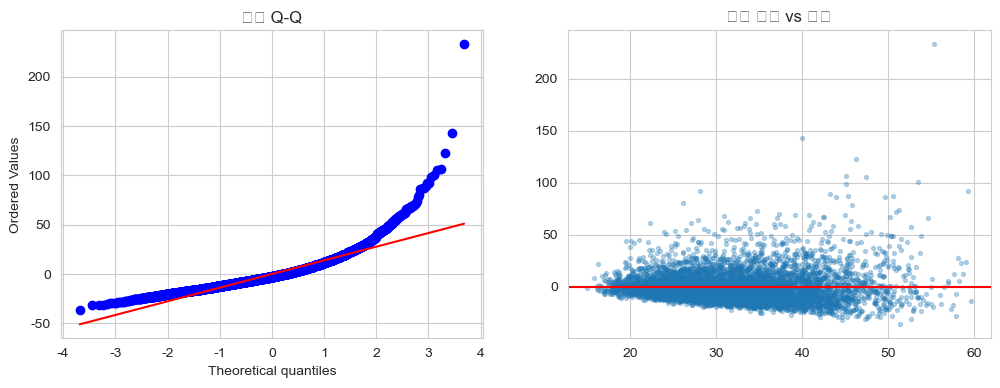

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51092 (\N{HANGUL SYLLABLE JAN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


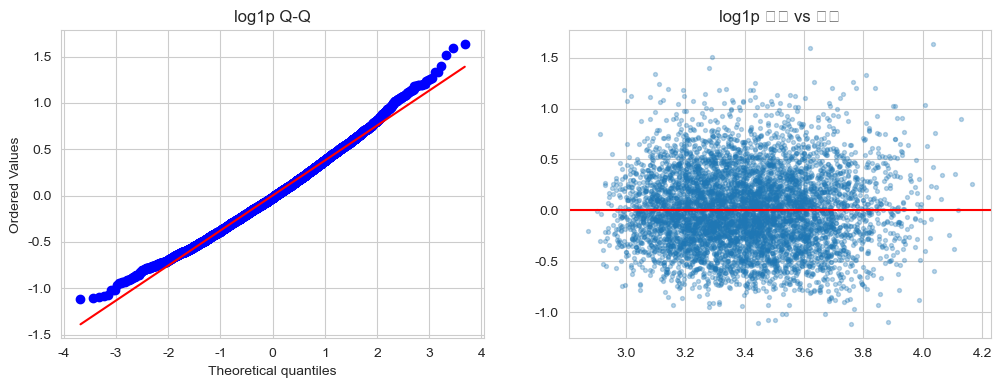

In [13]:
# 회귀모델의 잔차를 시각화하는 함수 정의
# model: 확인할 회귀모델
# title: 그래프 제목에 붙일 문자열
def resid_plots(model, title):

    # 1행 2열로 그래프 2개를 나란히 생성
    # fig: 전체 그림 객체
    # axes[0]: 왼쪽 그래프
    # axes[1]: 오른쪽 그래프
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # model.resid:
    # 실제값 - 모델의 예측값으로 계산된 잔차
    #
    # stats.probplot():
    # 잔차가 정규분포와 비슷한지 Q-Q plot으로 확인
    #
    # dist='norm':
    # 정규분포와 비교
    #
    # plot=axes[0]:
    # 왼쪽 그래프에 그리기
    stats.probplot(
        model.resid,
        dist='norm',
        plot=axes[0]
    )

    # title + ' Q-Q':
    # 전달받은 제목 뒤에 ' Q-Q'를 붙여 왼쪽 그래프 제목 설정
    axes[0].set_title(title + ' Q-Q')


    # model.fittedvalues:
    # 모델이 예측한 값
    #
    # model.resid:
    # 각 데이터의 잔차
    #
    # scatter():
    # 예측값과 잔차의 관계를 산점도로 그림
    #
    # s=8:
    # 점 크기를 8로 설정
    #
    # alpha=0.3:
    # 점을 반투명하게 설정
    axes[1].scatter(
        model.fittedvalues,
        model.resid,
        s=8,
        alpha=0.3
    )

    # y=0 위치에 빨간 가로선 추가
    # 잔차가 0을 중심으로 고르게 퍼지는지 보기 위한 기준선
    axes[1].axhline(0, color='red')

    # 오른쪽 그래프 제목 설정
    axes[1].set_title(title + ' 잔차 vs 예측')

    # 그래프 출력
    plt.show()


# 원본 monthly_spend를 예측한 다중회귀모델 m2의 잔차 확인
resid_plots(m2, '원본')


# 종속변수 monthly_spend에 log1p 변환을 적용한 새 회귀모델 생성
#
# np.log1p(monthly_spend):
# log(1 + monthly_spend)를 계산
#
# ~ 오른쪽에는 월 지출액을 설명할 변수들을 작성
#
# C(signup_channel), C(gender):
# 문자형 범주 변수를 더미변수로 변환해 사용
m2_log = smf.ols(
    'np.log1p(monthly_spend) ~ monthly_visits + avg_discount_rate '
    '+ online_ad_cost + C(signup_channel) + C(gender)',
    data=df
).fit()


# 로그변환 모델의 잔차 확인
resid_plots(m2_log, 'log1p')

> ✍️ 원본 대비 로그변환 모형의 잔차가 어떻게 개선되는지 서술하세요.

로그변환 후 잔차의 Q-Q plot은 원본보다 직선에 더 가깝게 나타나 잔차의 정규성이 개선되었다. 또한 잔차-예측값 그래프에서도 원본은 예측값이 커질수록 잔차의 퍼짐이 커지는 경향이 있었지만, 로그변환 후에는 잔차가 0을 중심으로 더 고르게 분포하였다. 따라서 로그변환은 극단값의 영향을 줄이고 잔차의 정규성과 등분산성을 개선하여 회귀모형의 가정을 더 잘 만족시키는 것으로 해석할 수 있다.

## Part 5. 타겟팅 (로지스틱 회귀)

**13~14. 로지스틱 회귀 & 오즈비 해석**


LR은 예/아니오와 같이 결과가 이분법적으로 나뉠 때 사용하는 회귀이다.
LR은 각 변수가 반응 확률을 얼마나 올리는지를 알려주므로 설명가능한 모델이다.

LR에서는 각 변수마다 가설을 세운다.
예를 들어 monthly_visits라면:
H_0: 방문 횟수는 캠페인 반응 여부와 관련이 없다.
H_1: 방문 횟수는 캠페인 반응 여부와 관련이 있다.

결과의 p-value는 아래와 같이 분석된다.
 p < 0.05 → 해당 변수는 반응 여부와 유의한 관련이 있음
p ≥ 0.05 → 관련이 있다고 말할 근거가 부족함


로지스틱 회귀 결과에는 coef가 나온다.
coef = 2일때 설명변수가 1 증가할 때 결과가 2 증가한다고 바로 읽었던 선형회귀와 다르게,
로지스틱 회귀의 결과는 log-odds라는 단위이므로 지수함수를 적용해서 odds ratio(오즈비)로 해석한다.

우선 odds는 성공 확률를 실패 확률로 나눈 것이다.
(성공 확률 = 0.8 실패 확률 = 0.2일 때 odds = 4)

odds ratio는 약자로 OR이라고 하며, 두 조건의 오즈를 비교한 비율이다.
예를 들어 방문 횟수의 오즈비가 1.20이면 방문 횟수가 1회 증가할 때 켐페인의 반응 오즈가 1.20배가 된다.

범주형 변수에 이를 적용하려면 하나를 기준으로 잡고 분석한다.

In [14]:
# responded(0 또는 1)를 여러 변수로 설명하는 로지스틱 회귀모형 생성
logit = smf.logit(
    'responded ~ age + monthly_visits + C(campaign_group) + C(membership_tier) '
    '+ C(signup_channel)',
    data=df
).fit()

# 로지스틱 회귀 결과표 출력
print(logit.summary())


# 회귀계수, p-value, 오즈비를 하나의 표로 정리
odds = pd.DataFrame({
    'coef': logit.params,                 # 로지스틱 회귀계수
    'p': logit.pvalues,                   # 각 변수의 p-value
    'odds_ratio': np.exp(logit.params)    # 계수에 exp를 적용하여 오즈비 계산
})

# 결과를 소수점 셋째 자리까지 출력
print(odds.round(3))

Optimization terminated successfully.
         Current function value: 0.512887
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:              responded   No. Observations:                 6000
Model:                          Logit   Df Residuals:                     5991
Method:                           MLE   Df Model:                            8
Date:                Wed, 15 Jul 2026   Pseudo R-squ.:                 0.06405
Time:                        00:45:50   Log-Likelihood:                -3077.3
converged:                       True   LL-Null:                       -3287.9
Covariance Type:            nonrobust   LLR p-value:                 5.453e-86
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                              -2.2301      0.157 

> ✍️ 쿠폰 발송·멤버십 등급의 오즈비를 해석하고, 다음 캠페인 타겟 세그먼트를 정하세요.

쿠폰 발송(campaign_group=treatment)의 오즈비는 약 2.43배(exp(0.8895) ≈ 2.43)이며, p-value가 0.001보다 작아 통계적으로 유의하다. 즉, 쿠폰을 받은 고객은 받지 않은 고객보다 캠페인에 반응할 오즈가 약 2.4배 높다.

멤버십 등급에서는 Gold 회원의 오즈비가 약 2.02배(exp(0.7024) ≈ 2.02), Silver 회원의 오즈비가 약 1.41배(exp(0.3411) ≈ 1.41)로 모두 p-value가 0.05보다 작아 유의한 차이를 보였다. 즉, Gold 회원이 가장 반응 가능성이 높고, 그다음이 Silver, Basic 순으로 해석할 수 있다.

따라서 다음 캠페인은 Gold 및 Silver 회원을 우선 대상으로 하고, 쿠폰을 적극적으로 발송하는 전략이 가장 효과적일 것으로 판단된다.

## 종합 결론 — CMO 보고용 마케팅 전략

> ✍️ Part 1~5를 종합해 (1) 캠페인 지속 여부 (2) 채널 예산 배분 (3) 매출 레버 (4) 타겟팅 (5) 분석 한계를 담은 한 장짜리 전략을 서술하세요. (report.pdf의 핵심)